# Kyrgyzstan Socio-Economic Data Analysis (2000–2023)

**Course:** Applied Statistics & Data Visualization  
**Dataset:** National and regional indicators for the Kyrgyz Republic  
**Sources:** World Bank Open Data, National Statistical Committee of the Kyrgyz Republic  

---

## Project Overview

This notebook covers the full data wrangling pipeline:
1. Dataset Acquisition & Loading
2. Data Cleaning (missing values, duplicates, outliers, types)
3. Data Transformation (new features, encoding, normalization)
4. Exploratory Data Analysis (EDA) with summary statistics
5. Visualization (12+ plots)
6. Key Insights & Conclusions

### Running on Kaggle

1. Upload the two raw CSV files (`kyrgyzstan_national_indicators_raw.csv`, `kyrgyzstan_regional_indicators_raw.csv`) as a Kaggle dataset.
2. Add the dataset to this notebook via **+ Add Data**.
3. In the **Imports & Configuration** cell below, set `KAGGLE_DATASET_SLUG` to the slug of your dataset (the last part of `kaggle.com/datasets/alydinus/<slug>`).
4. Run all cells — outputs go to `/kaggle/working/` automatically.

> **Note:** Never write to `/kaggle/input/` — it is read-only. All cleaned CSVs and plots are saved to `/kaggle/working/`.

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
import os

warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Environment detection ──────────────────────────────────────────────────
# /kaggle/input/ is read-only on Kaggle; outputs must go to /kaggle/working/
ON_KAGGLE = os.path.exists('/kaggle/working')

if ON_KAGGLE:
    # Update this slug to match your Kaggle dataset name
    # (the last part of https://www.kaggle.com/datasets/alydinus/<slug>)
    KAGGLE_DATASET_SLUG = 'nsc-kyrgyzstan'
    DATA_INPUT_DIR  = f'/kaggle/input/{KAGGLE_DATASET_SLUG}'
    DATA_OUTPUT_DIR = '/kaggle/working'
    VIZ_DIR         = '/kaggle/working/visualizations'
else:
    DATA_INPUT_DIR  = 'data'
    DATA_OUTPUT_DIR = 'data'
    VIZ_DIR         = 'visualizations'

os.makedirs(VIZ_DIR, exist_ok=True)
if not ON_KAGGLE:
    os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)

# Verify input files are accessible
_raw_nat = f'{DATA_INPUT_DIR}/kyrgyzstan_national_indicators_raw.csv'
_raw_reg = f'{DATA_INPUT_DIR}/kyrgyzstan_regional_indicators_raw.csv'
if not os.path.exists(_raw_nat):
    raise FileNotFoundError(
        f'Raw data not found at {DATA_INPUT_DIR}/\n'
        + ('  → Update KAGGLE_DATASET_SLUG above to match your Kaggle dataset slug.' if ON_KAGGLE
           else '  → Run data/generate_dataset.py first to create the raw CSV files.')
    )

print(f'Running on: {"Kaggle" if ON_KAGGLE else "Local"} environment')
print(f'  Input  → {DATA_INPUT_DIR}')
print(f'  Output → {DATA_OUTPUT_DIR}')
print(f'  Plots  → {VIZ_DIR}')

KYRGYZ_COLORS = ['#E63946', '#457B9D', '#1D3557', '#A8DADC', '#F4A261',
                 '#2A9D8F', '#E9C46A', '#264653', '#6A4C93']

print('Libraries loaded successfully.')

---
## 2. Dataset Acquisition & Loading

We work with two datasets:
- **National dataset** – 24 rows (one per year 2000–2023), 11 macro-economic indicators
- **Regional dataset** – 216 rows (9 regions × 24 years), 10 socio-demographic indicators

In [2]:
nat = pd.read_csv(f'{DATA_INPUT_DIR}/kyrgyzstan_national_indicators_raw.csv')
reg = pd.read_csv(f'{DATA_INPUT_DIR}/kyrgyzstan_regional_indicators_raw.csv')

print('=== National Dataset ===')
print(f'Shape: {nat.shape}')
print(nat.dtypes)
print('\n=== Regional Dataset ===')
print(f'Shape: {reg.shape}')
print(reg.dtypes)

=== National Dataset ===
Shape: (24, 11)
year                       int64
gdp_per_capita_usd         int64
population_millions      float64
inflation_rate_pct       float64
unemployment_rate_pct    float64
literacy_rate_pct        float64
life_expectancy_years    float64
remittances_pct_gdp      float64
exports_usd_bn           float64
internet_users_pct       float64
co2_emissions_kt         float64
dtype: object

=== Regional Dataset ===
Shape: (216, 10)
year                      int64
region                      str
population_thousands    float64
gdp_per_capita_usd      float64
poverty_rate_pct        float64
urban_population_pct    float64
num_schools               int64
num_hospitals           float64
area_km2                  int64
population_density      float64
dtype: object


In [3]:
nat.head()

,year,gdp_per_capita_usd,population_millions,inflation_rate_pct,unemployment_rate_pct,literacy_rate_pct,life_expectancy_years,remittances_pct_gdp,exports_usd_bn,internet_users_pct,co2_emissions_kt
0,2000,280,4.90,18.79,7.48,98.1,65.2,2.1,0.51,1.0,6215.81
1,2001,305,4.97,6.88,7.80,98.2,65.5,2.5,0.48,NaN,5718.89
2,2002,330,5.03,2.22,7.47,98.3,65.8,3.0,0.49,NaN,5614.91
3,2003,370,5.10,3.37,9.01,98.4,66.1,5.0,0.58,3.1,6082.28
4,2004,430,5.17,4.06,8.48,98.5,66.4,7.5,0.73,4.0,6468.86


In [4]:
reg.head()

,year,region,population_thousands,gdp_per_capita_usd,poverty_rate_pct,urban_population_pct,num_schools,num_hospitals,area_km2,population_density
0,2000,Bishkek,848.4,577.0,7.4,99.8,215,50.0,127,6680.31
1,2001,Bishkek,860.1,597.0,6.4,100.0,219,54.0,127,6772.44
2,2002,Bishkek,958.8,750.0,5.4,100.0,214,51.0,127,7549.61
3,2003,Bishkek,829.7,816.0,6.4,100.0,216,52.0,127,6533.07
4,2004,Bishkek,932.0,851.0,4.5,99.9,223,50.0,127,7338.58


---
## 3. Data Cleaning

### 3.1 Standardise Column Names

In [5]:
def standardise_columns(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(r'[\s\-]+', '_', regex=True))
    return df

nat = standardise_columns(nat)
reg = standardise_columns(reg)
print('Columns standardised.')
print(nat.columns.tolist())

Columns standardised.
['year', 'gdp_per_capita_usd', 'population_millions', 'inflation_rate_pct', 'unemployment_rate_pct', 'literacy_rate_pct', 'life_expectancy_years', 'remittances_pct_gdp', 'exports_usd_bn', 'internet_users_pct', 'co2_emissions_kt']


### 3.2 Check & Handle Missing Values

In [6]:
print('=== Missing Values – National ===')
nat_miss = nat.isnull().sum()
print(nat_miss[nat_miss > 0])

print('\n=== Missing Values – Regional ===')
reg_miss = reg.isnull().sum()
print(reg_miss[reg_miss > 0])

=== Missing Values – National ===
exports_usd_bn        1
internet_users_pct    2
dtype: int64

=== Missing Values – Regional ===
poverty_rate_pct    6
num_hospitals       4
dtype: int64


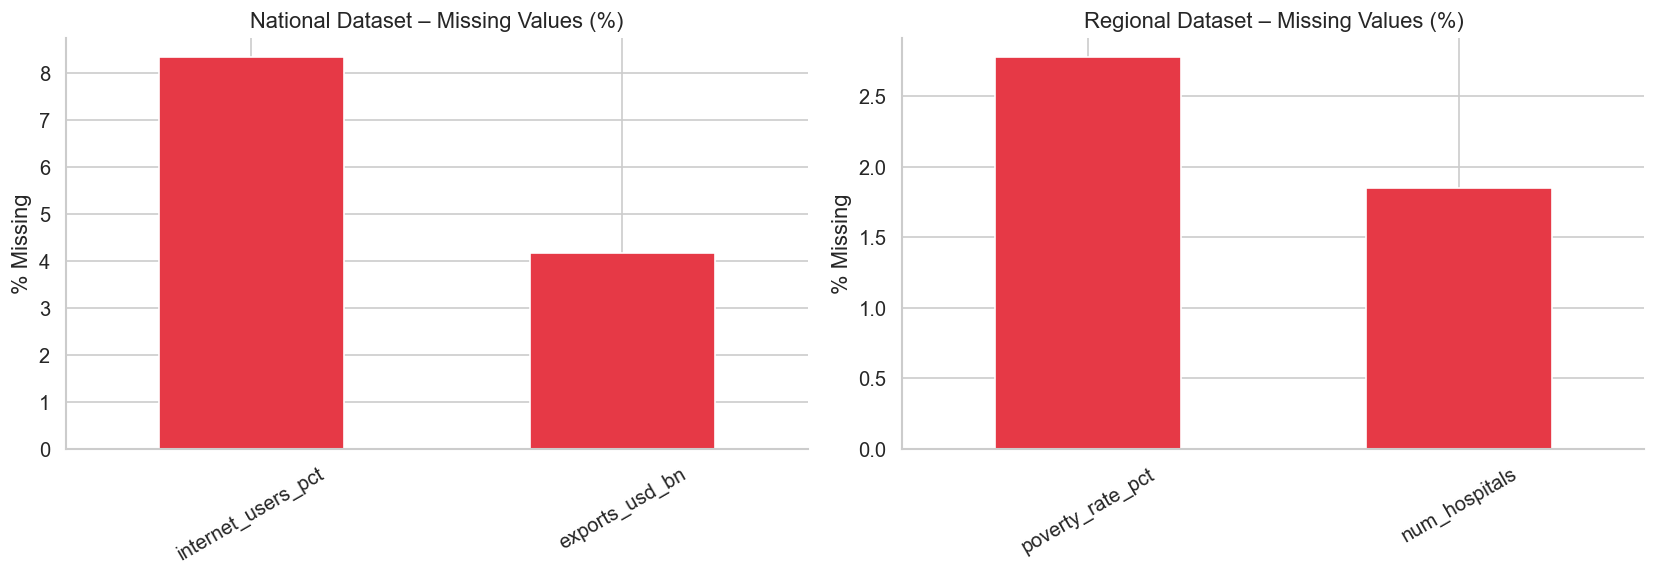

In [7]:
# Visualise missing data pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [nat, reg], ['National', 'Regional']):
    miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    if miss_pct.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
    else:
        miss_pct.plot(kind='bar', ax=ax, color='#E63946', edgecolor='white')
        ax.set_title(f'{title} Dataset – Missing Values (%)')
        ax.set_ylabel('% Missing')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/01_missing_values.png')
plt.show()

In [8]:
# National: interpolate time-series gaps with linear interpolation
nat['internet_users_pct'] = nat['internet_users_pct'].interpolate(method='linear')
nat['exports_usd_bn'] = nat['exports_usd_bn'].interpolate(method='linear')

# Regional: fill poverty with region-year median; hospitals with region median
reg['poverty_rate_pct'] = reg.groupby('region')['poverty_rate_pct'].transform(
    lambda x: x.fillna(x.median()))
reg['num_hospitals'] = reg.groupby('region')['num_hospitals'].transform(
    lambda x: x.fillna(x.median()))

print('Missing values after cleaning:')
print(f'  National  – {nat.isnull().sum().sum()} remaining')
print(f'  Regional  – {reg.isnull().sum().sum()} remaining')

Missing values after cleaning:
  National  – 0 remaining
  Regional  – 0 remaining


### 3.3 Data Type Conversion

In [9]:
nat['year'] = nat['year'].astype(int)
reg['year'] = reg['year'].astype(int)
reg['region'] = reg['region'].astype('category')
reg['num_schools'] = reg['num_schools'].astype(int)
reg['num_hospitals'] = reg['num_hospitals'].round(0).astype(int)

print('Data types corrected.')
print(reg.dtypes)

Data types corrected.
year                       int64
region                  category
population_thousands     float64
gdp_per_capita_usd       float64
poverty_rate_pct         float64
urban_population_pct     float64
num_schools                int64
num_hospitals              int64
area_km2                   int64
population_density       float64
dtype: object


### 3.4 Duplicate Detection

In [10]:
nat_dups = nat.duplicated().sum()
reg_dups = reg.duplicated().sum()
print(f'Duplicates – National: {nat_dups}, Regional: {reg_dups}')
nat.drop_duplicates(inplace=True)
reg.drop_duplicates(inplace=True)

Duplicates – National: 0, Regional: 0


### 3.5 Outlier Detection & Treatment

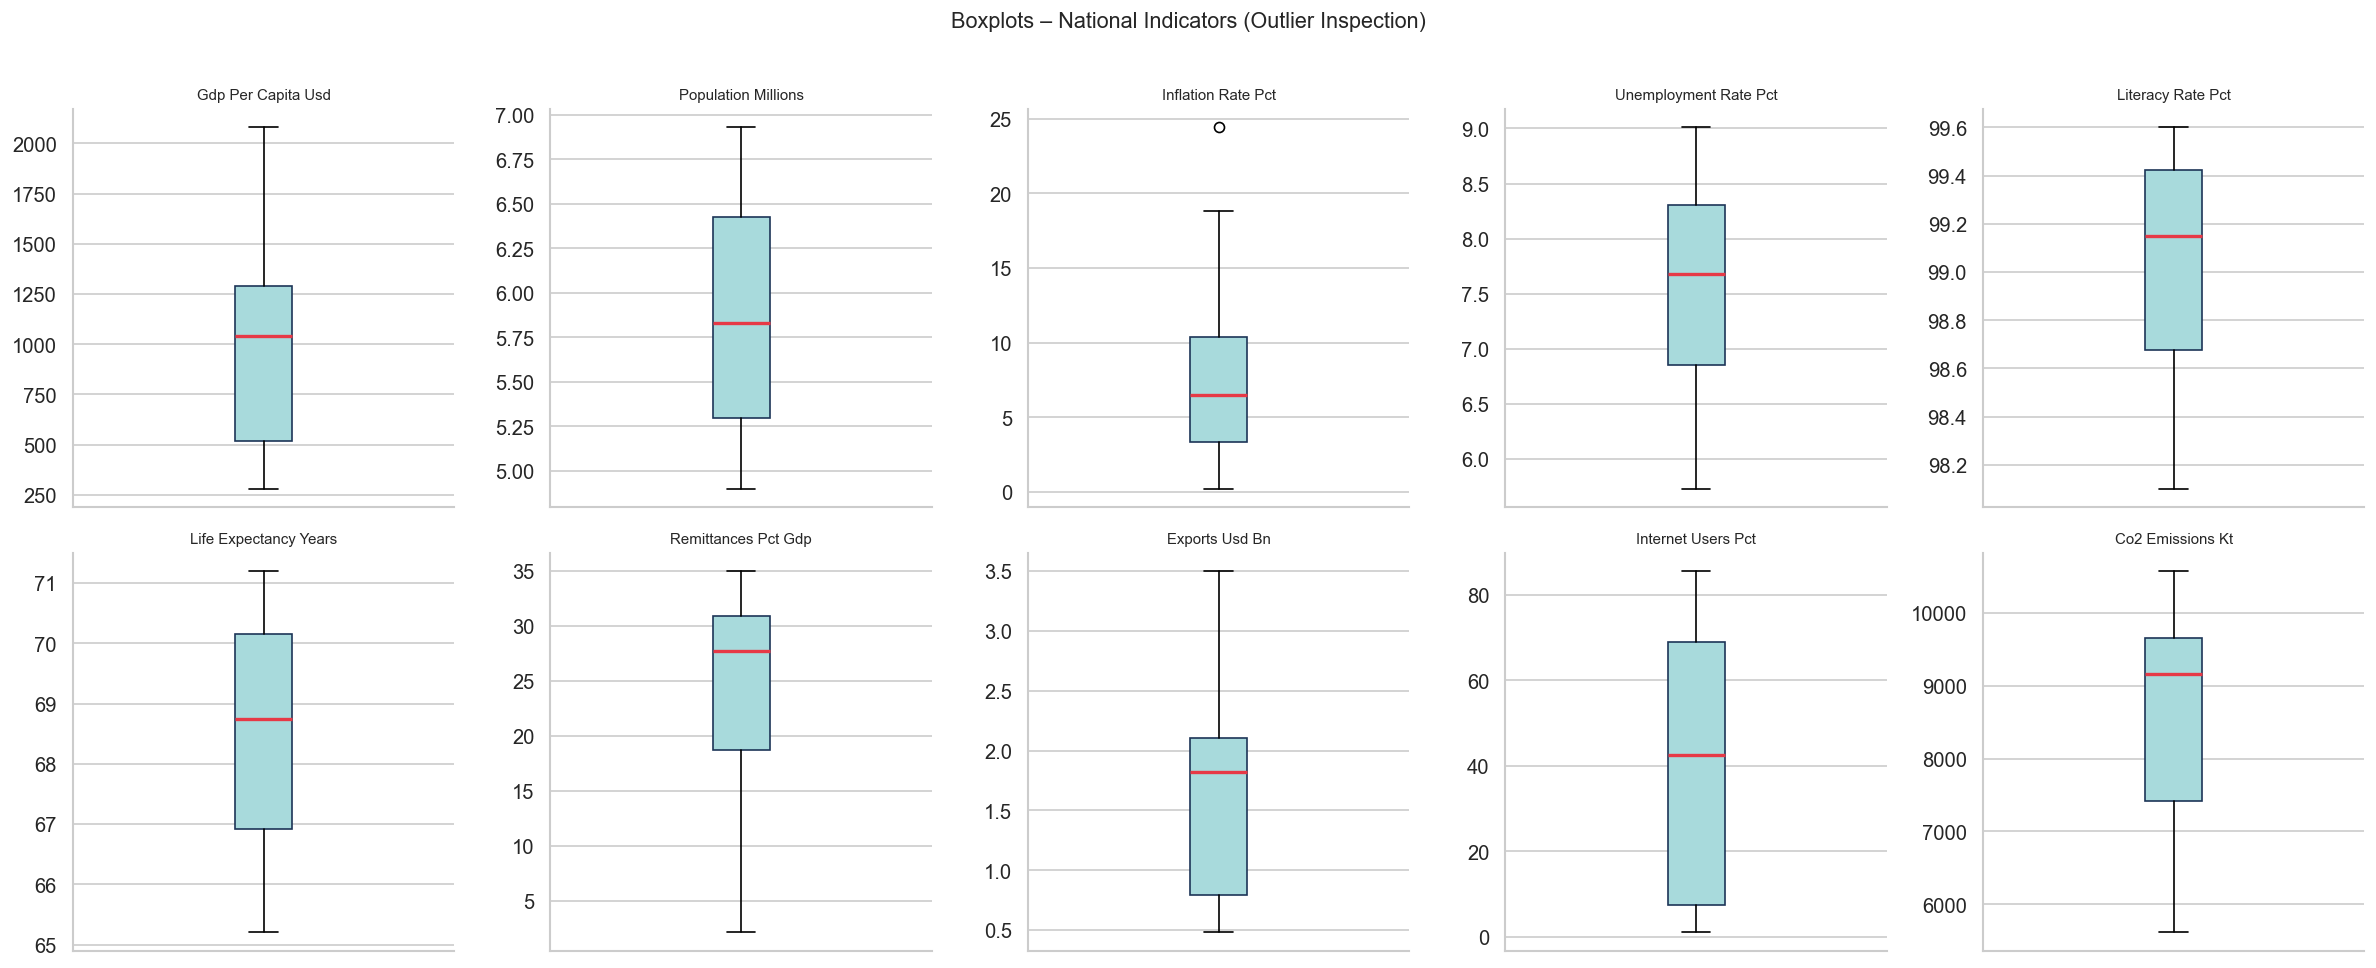

In [11]:
numeric_nat = nat.select_dtypes(include='number').drop(columns=['year'])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_nat.columns):
    axes[i].boxplot(nat[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#A8DADC', color='#1D3557'),
                   medianprops=dict(color='#E63946', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots – National Indicators (Outlier Inspection)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/02_boxplots_outliers.png')
plt.show()

In [12]:
# Use IQR method to flag (not remove) outliers in the national dataset
outlier_report = {}
for col in numeric_nat.columns:
    Q1 = nat[col].quantile(0.25)
    Q3 = nat[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = nat[(nat[col] < lower) | (nat[col] > upper)]
    if not outliers.empty:
        outlier_report[col] = outliers[['year', col]].values.tolist()

print('Detected outliers (kept – contextually valid extreme years):')
for col, rows in outlier_report.items():
    print(f'  {col}: years {[r[0] for r in rows]} → values {[round(r[1],2) for r in rows]}')

Detected outliers (kept – contextually valid extreme years):
  inflation_rate_pct: years [2008.0] → values [24.42]


> **Note:** Identified outliers (e.g. 2008 inflation spike, 2020 COVID dip) are **retained** because they reflect genuine historical events, not data entry errors.

---
## 4. Data Transformation

### 4.1 Derived / Calculated Columns

In [13]:
# Year-on-year GDP per capita growth rate
nat['gdp_growth_pct'] = nat['gdp_per_capita_usd'].pct_change() * 100

# Total population in millions  
nat['total_population_m'] = nat['population_millions']

# Human Development proxy index (normalised average of life expectancy, literacy, log-GDP)
nat['log_gdp'] = np.log(nat['gdp_per_capita_usd'])
scaler_hdi = MinMaxScaler()
hdi_inputs = nat[['life_expectancy_years', 'literacy_rate_pct', 'log_gdp']].copy()
nat['hdi_proxy'] = scaler_hdi.fit_transform(hdi_inputs).mean(axis=1).round(4)

# Remittance-to-export ratio (financial dependency indicator)
nat['remittance_export_ratio'] = (nat['remittances_pct_gdp'] / nat['exports_usd_bn']).round(3)

# Regional: infrastructure density (schools + hospitals per 1000 population)
reg['infra_per_1000'] = ((reg['num_schools'] + reg['num_hospitals']) /
                         (reg['population_thousands'])).round(4)

# Regional: categorical development tier based on GDP per capita
def dev_tier(gdp):
    if gdp >= 1500: return 'High'
    elif gdp >= 800: return 'Medium'
    else: return 'Low'

reg['dev_tier'] = reg['gdp_per_capita_usd'].apply(dev_tier)

# Track original column names for reporting
_nat_orig_cols = list(pd.read_csv(f'{DATA_INPUT_DIR}/kyrgyzstan_national_indicators_raw.csv').columns)
_reg_orig_cols = list(pd.read_csv(f'{DATA_INPUT_DIR}/kyrgyzstan_regional_indicators_raw.csv').columns)

print('New columns added to National dataset:')
print([c for c in nat.columns if c not in _nat_orig_cols])
print('\nNew columns added to Regional dataset:')
print([c for c in reg.columns if c not in _reg_orig_cols])

New columns added to National dataset:
['gdp_growth_pct', 'total_population_m', 'log_gdp', 'hdi_proxy', 'remittance_export_ratio']

New columns added to Regional dataset:
['infra_per_1000', 'dev_tier']


### 4.2 Normalisation (Min-Max Scaling)

In [14]:
cols_to_scale = ['gdp_per_capita_usd', 'inflation_rate_pct',
                 'unemployment_rate_pct', 'internet_users_pct']
scaler = MinMaxScaler()
nat_scaled = nat.copy()
nat_scaled[[c + '_norm' for c in cols_to_scale]] = scaler.fit_transform(nat[cols_to_scale])

print('Normalised columns added:')
nat_scaled[[c + '_norm' for c in cols_to_scale]].describe().round(3)

Normalised columns added:


,gdp_per_capita_usd_norm,inflation_rate_pct_norm,unemployment_rate_pct_norm,internet_users_pct_norm
count,24.000,24.000,24.000,24.000
mean,0.397,0.310,0.551,0.468
std,0.291,0.245,0.288,0.364
min,0.000,0.000,0.000,0.000
25%,0.132,0.129,0.341,0.075
50%,0.422,0.259,0.595,0.491
75%,0.561,0.420,0.784,0.805
max,1.000,1.000,1.000,1.000


### 4.3 Categorical Encoding

In [15]:
# Label encoding for development tier (ordinal)
le = LabelEncoder()
tier_map = {'Low': 0, 'Medium': 1, 'High': 2}
reg['dev_tier_encoded'] = reg['dev_tier'].map(tier_map)

# One-hot encoding for region (for potential ML use)
reg_ohe = pd.get_dummies(reg, columns=['region'], prefix='reg', dtype=int)

print('Label encoding:')
print(reg[['region', 'dev_tier', 'dev_tier_encoded']].drop_duplicates().head(9).to_string(index=False))

Label encoding:
  region dev_tier  dev_tier_encoded
 Bishkek      Low                 0
 Bishkek   Medium                 1
 Bishkek     High                 2
Osh City      Low                 0
Osh City   Medium                 1
Osh City     High                 2
    Chuy      Low                 0
    Chuy   Medium                 1
    Chuy     High                 2


### 4.4 Pivot / Reshape

In [16]:
# Pivot: regions as columns, poverty rate by year
poverty_pivot = reg.pivot_table(
    index='year', columns='region', values='poverty_rate_pct', aggfunc='mean'
)
print('Poverty rate pivot table (first 5 years):')
poverty_pivot.head()

Poverty rate pivot table (first 5 years):


region,Batken,Bishkek,Chuy,Issyk-Kul,Jalal-Abad,Naryn,Osh,Osh City,Talas
year,,,,,,,,,
2000,40.6,7.4,15.1,27.2,39.0,46.0,37.8,12.6,33.4
2001,40.3,6.4,19.1,26.6,35.5,43.8,38.9,11.6,31.8
2002,40.8,5.4,18.5,27.2,38.3,44.8,39.2,11.5,32.8
2003,40.8,6.4,17.9,24.8,38.0,44.2,39.3,13.8,32.3
2004,39.5,4.5,19.1,22.7,36.3,45.8,39.6,11.2,35.3


### 4.5 Save Cleaned Datasets

In [17]:
nat.to_csv(f'{DATA_OUTPUT_DIR}/kyrgyzstan_national_cleaned.csv', index=False)
reg.to_csv(f'{DATA_OUTPUT_DIR}/kyrgyzstan_regional_cleaned.csv', index=False)
print(f'Cleaned datasets saved to: {DATA_OUTPUT_DIR}/')

Cleaned datasets saved to: data/


---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Summary Statistics – National Indicators

In [18]:
nat.describe().round(2)

,year,gdp_per_capita_usd,population_millions,inflation_rate_pct,unemployment_rate_pct,literacy_rate_pct,life_expectancy_years,remittances_pct_gdp,exports_usd_bn,internet_users_pct,co2_emissions_kt,gdp_growth_pct,total_population_m,log_gdp,hdi_proxy,remittance_export_ratio
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,23.00,24.00,24.00,24.00,24.00
mean,2011.50,995.21,5.87,7.72,7.54,99.03,68.49,22.73,1.69,40.51,8487.79,9.38,5.87,6.74,0.57,13.58
std,7.07,524.19,0.65,5.92,0.94,0.47,1.87,10.98,0.86,30.74,1543.45,7.70,0.65,0.61,0.31,5.71
min,2000.00,280.00,4.90,0.22,5.73,98.10,65.20,2.10,0.48,1.00,5614.91,-12.70,4.90,5.63,0.00,4.12
25%,2005.75,517.50,5.30,3.34,6.85,98.68,66.92,18.75,0.79,7.38,7417.61,7.03,5.30,6.25,0.33,10.10
50%,2011.50,1040.00,5.83,6.48,7.68,99.15,68.75,27.75,1.82,42.50,9157.60,9.43,5.83,6.95,0.65,12.97
75%,2017.25,1290.00,6.43,10.39,8.30,99.43,70.15,30.90,2.10,69.00,9652.42,12.88,6.43,7.16,0.82,15.85
max,2023.00,2080.00,6.93,24.42,9.01,99.60,71.20,35.00,3.50,85.50,10570.76,22.86,6.93,7.64,1.00,27.16


### 5.2 Summary Statistics – Regional Indicators

In [19]:
reg.groupby('region')[['gdp_per_capita_usd', 'poverty_rate_pct',
                        'population_thousands', 'infra_per_1000']].mean().round(2)

,gdp_per_capita_usd,poverty_rate_pct,population_thousands,infra_per_1000
region,,,,
Batken,701.71,41.00,501.87,0.53
Bishkek,2026.62,5.53,978.59,0.28
Chuy,1264.21,18.04,807.05,0.44
Issyk-Kul,1217.08,25.45,429.54,0.53
Jalal-Abad,681.38,35.45,1014.85,0.54
Naryn,684.79,44.85,254.41,0.79
Osh,672.50,38.50,1182.93,0.55
Osh City,2023.12,12.33,294.02,0.32
Talas,665.96,32.30,228.05,0.71


### 5.3 Correlation Matrix

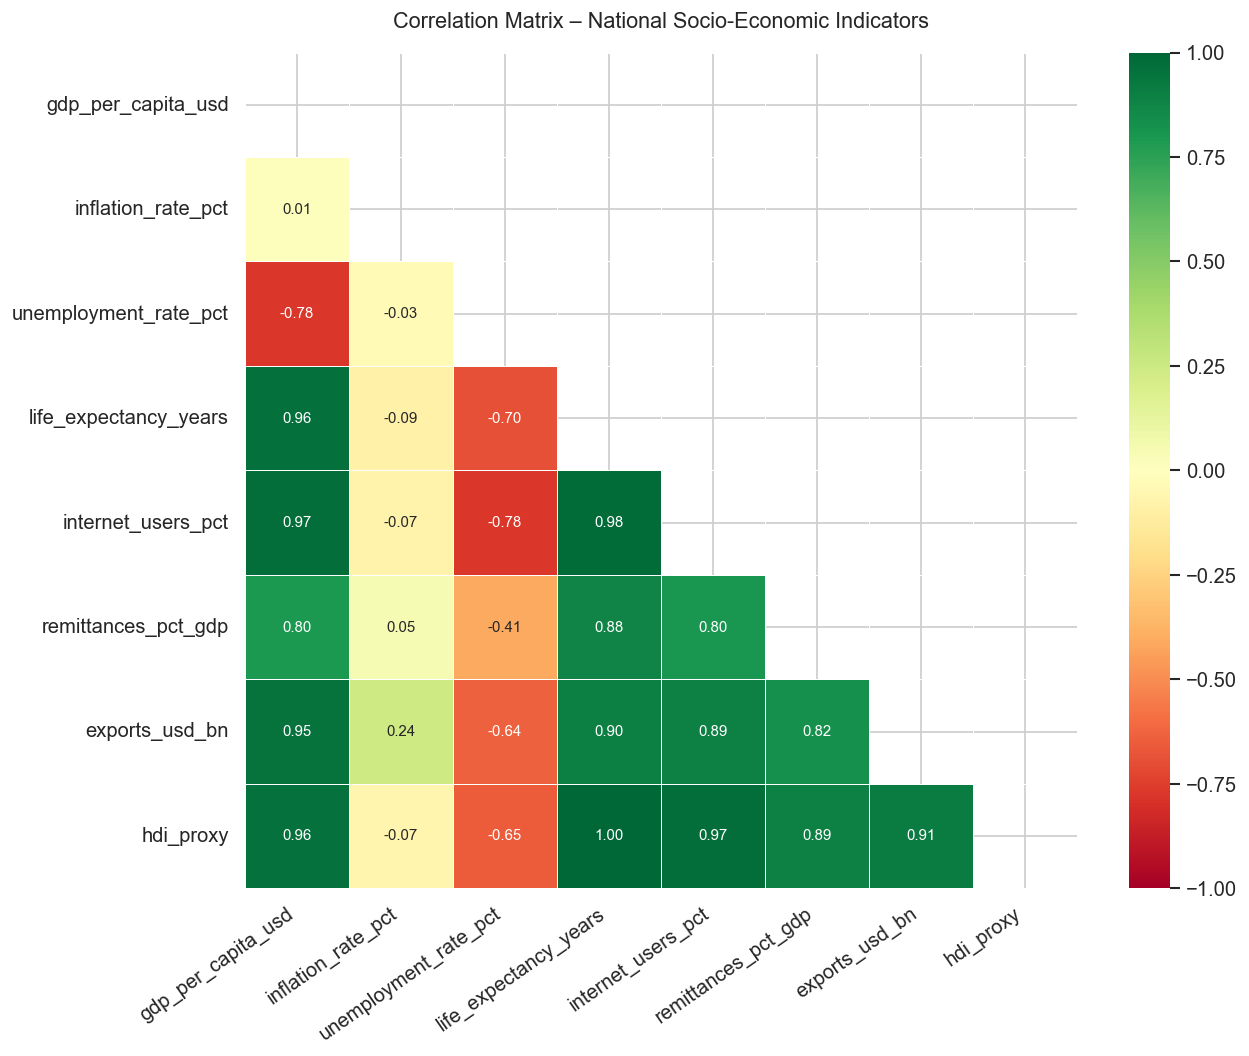


Top positive correlations with GDP per capita:
internet_users_pct       0.973
life_expectancy_years    0.964
hdi_proxy                0.959
exports_usd_bn           0.950
remittances_pct_gdp      0.796
inflation_rate_pct       0.013
unemployment_rate_pct   -0.780
Name: gdp_per_capita_usd, dtype: float64


In [20]:
corr_cols = ['gdp_per_capita_usd', 'inflation_rate_pct', 'unemployment_rate_pct',
             'life_expectancy_years', 'internet_users_pct', 'remittances_pct_gdp',
             'exports_usd_bn', 'hdi_proxy']
corr_matrix = nat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix – National Socio-Economic Indicators', fontsize=13, pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/03_correlation_heatmap.png')
plt.show()

print('\nTop positive correlations with GDP per capita:')
top_corr = corr_matrix['gdp_per_capita_usd'].drop('gdp_per_capita_usd').sort_values(ascending=False)
print(top_corr.round(3))

---
## 6. Visualizations

### 6.1 GDP per Capita Growth Trend (2000–2023)

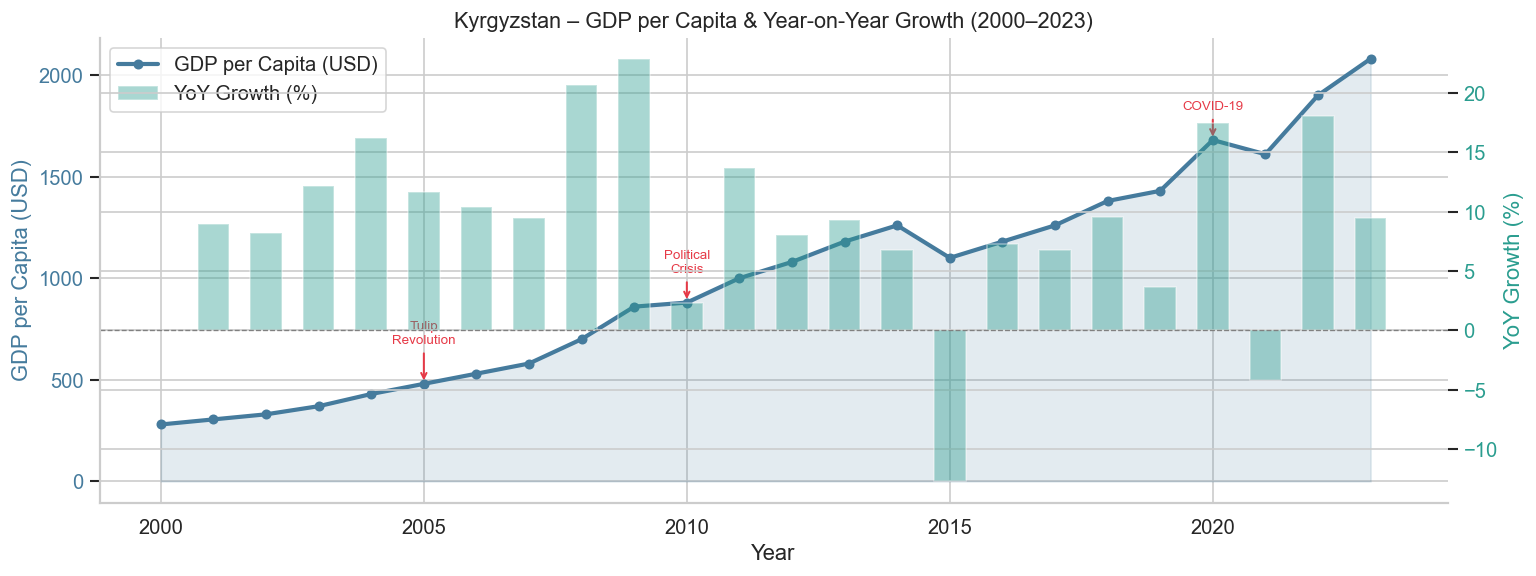

In [21]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.fill_between(nat['year'], nat['gdp_per_capita_usd'], alpha=0.15, color='#457B9D')
ax1.plot(nat['year'], nat['gdp_per_capita_usd'], color='#457B9D', linewidth=2.5,
         marker='o', markersize=5, label='GDP per Capita (USD)')

# Annotate key events
events = {
    2005: ('Tulip\nRevolution', 530),
    2010: ('Political\nCrisis', 880),
    2020: ('COVID-19', 1680),
}
for year, (label, y) in events.items():
    ax1.annotate(label, xy=(year, nat.loc[nat['year'] == year, 'gdp_per_capita_usd'].values[0]),
                xytext=(year, y + 150), fontsize=8, color='#E63946',
                arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.2),
                ha='center')

ax2 = ax1.twinx()
ax2.bar(nat['year'], nat['gdp_growth_pct'], alpha=0.4, color='#2A9D8F',
        label='YoY Growth (%)', width=0.6)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_ylabel('YoY Growth (%)', color='#2A9D8F')
ax2.tick_params(axis='y', labelcolor='#2A9D8F')

ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per Capita (USD)', color='#457B9D')
ax1.tick_params(axis='y', labelcolor='#457B9D')
ax1.set_title('Kyrgyzstan – GDP per Capita & Year-on-Year Growth (2000–2023)', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/04_gdp_trend.png')
plt.show()

**Insight 1 – GDP Growth:** Kyrgyzstan's GDP per capita grew **7.4×** from 2000 to 2023 (\$280 → \$2,080). The steepest decline occurred in 2009 (global financial crisis) and 2020 (COVID-19), both followed by rapid recoveries.

### 6.2 Remittances vs. Exports – Structural Dependency

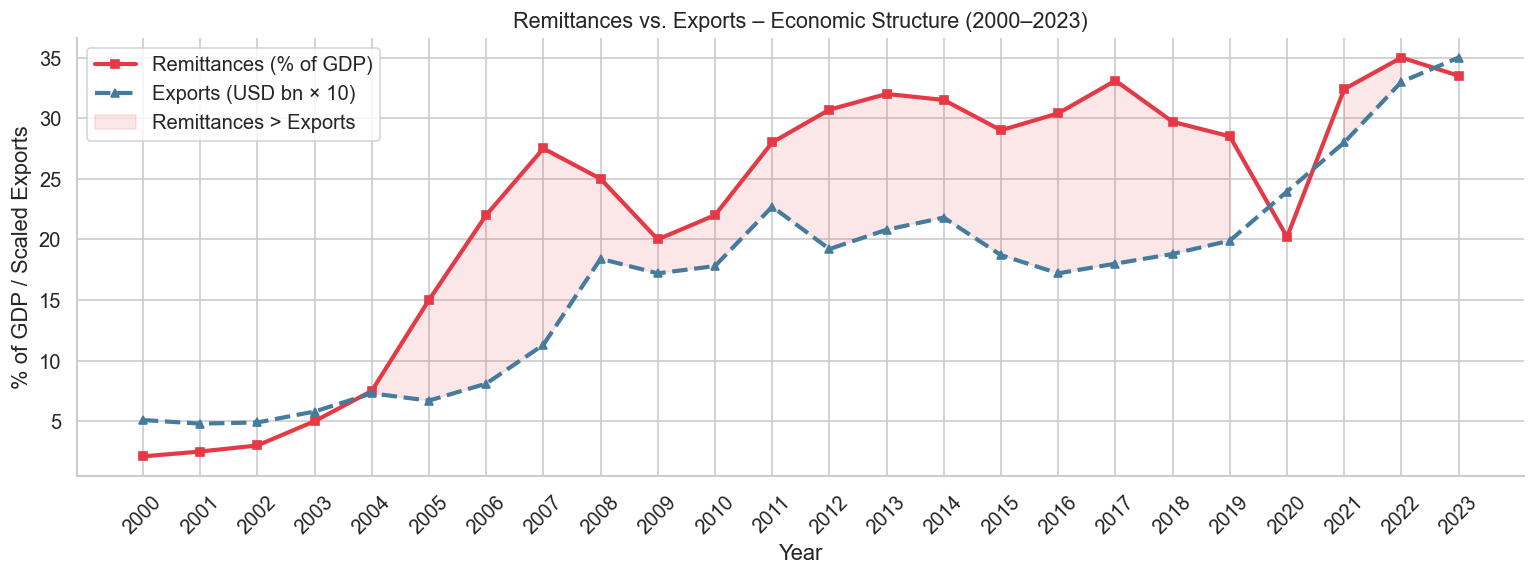

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(nat['year'], nat['remittances_pct_gdp'], color='#E63946', linewidth=2.5,
        marker='s', markersize=5, label='Remittances (% of GDP)')
ax.plot(nat['year'], nat['exports_usd_bn'] * 10, color='#457B9D', linewidth=2.5,
        marker='^', markersize=5, linestyle='--', label='Exports (USD bn × 10)')

ax.fill_between(nat['year'], nat['remittances_pct_gdp'], nat['exports_usd_bn'] * 10,
               where=nat['remittances_pct_gdp'] > nat['exports_usd_bn'] * 10,
               alpha=0.12, color='#E63946', label='Remittances > Exports')

ax.set_title('Remittances vs. Exports – Economic Structure (2000–2023)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('% of GDP / Scaled Exports')
ax.legend()
ax.set_xticks(nat['year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/05_remittances_vs_exports.png')
plt.show()

**Insight 2 – Remittance Dependency:** Since 2005, remittances have consistently exceeded exports as a share of GDP, reaching **35% of GDP** in 2022. This makes Kyrgyzstan one of the most remittance-dependent economies in the world, indicating significant vulnerability to labour market conditions in Russia and Kazakhstan.

### 6.3 Inflation & Unemployment Rates Over Time

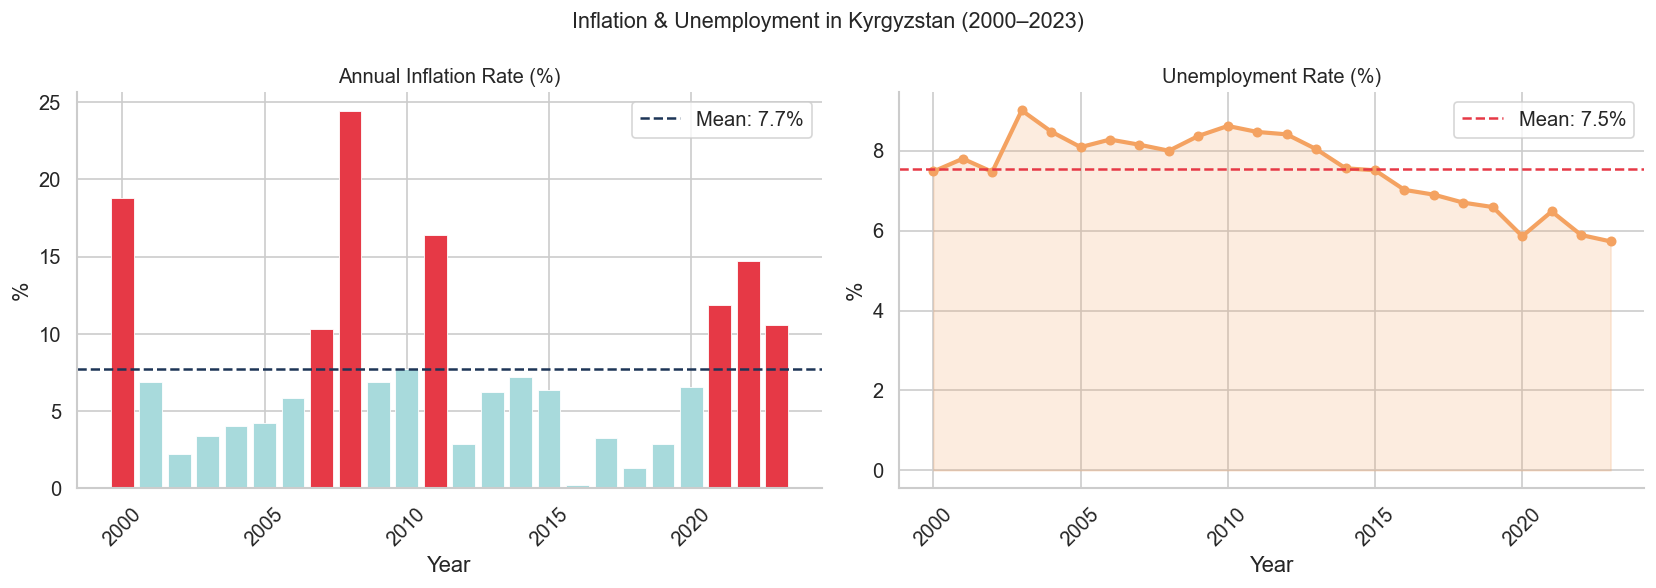

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inflation
axes[0].bar(nat['year'], nat['inflation_rate_pct'],
            color=['#E63946' if v > 10 else '#A8DADC' for v in nat['inflation_rate_pct']],
            edgecolor='white', linewidth=0.5)
axes[0].axhline(nat['inflation_rate_pct'].mean(), color='#1D3557', linestyle='--', linewidth=1.5,
               label=f'Mean: {nat["inflation_rate_pct"].mean():.1f}%')
axes[0].set_title('Annual Inflation Rate (%)', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Unemployment
axes[1].plot(nat['year'], nat['unemployment_rate_pct'], color='#F4A261',
             linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(nat['year'], nat['unemployment_rate_pct'], alpha=0.2, color='#F4A261')
axes[1].axhline(nat['unemployment_rate_pct'].mean(), color='#E63946', linestyle='--',
               label=f'Mean: {nat["unemployment_rate_pct"].mean():.1f}%')
axes[1].set_title('Unemployment Rate (%)', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Inflation & Unemployment in Kyrgyzstan (2000–2023)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/06_inflation_unemployment.png')
plt.show()

### 6.4 Life Expectancy & HDI Proxy Trend

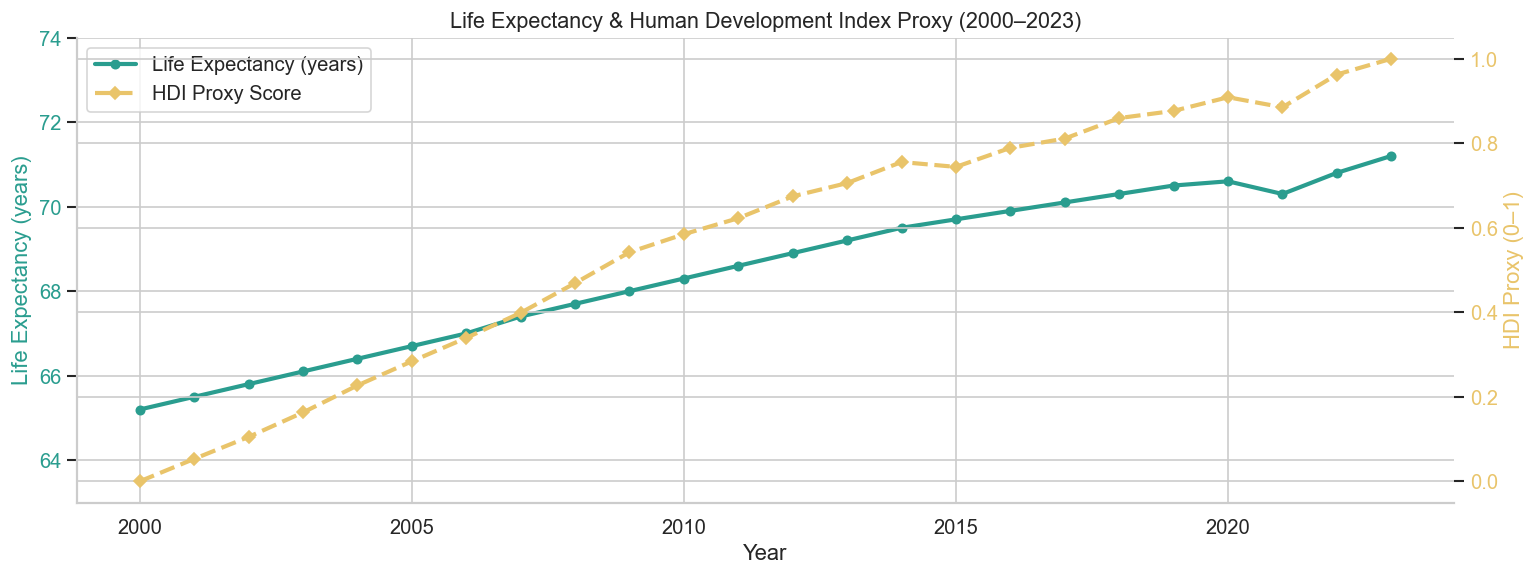

In [24]:
fig, ax1 = plt.subplots(figsize=(13, 5))

color1, color2 = '#2A9D8F', '#E9C46A'
ax1.plot(nat['year'], nat['life_expectancy_years'], color=color1, linewidth=2.5,
         marker='o', markersize=5, label='Life Expectancy (years)')
ax1.set_ylabel('Life Expectancy (years)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(63, 74)

ax2 = ax1.twinx()
ax2.plot(nat['year'], nat['hdi_proxy'], color=color2, linewidth=2.5,
         marker='D', markersize=5, linestyle='--', label='HDI Proxy Score')
ax2.set_ylabel('HDI Proxy (0–1)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_xlabel('Year')
ax1.set_title('Life Expectancy & Human Development Index Proxy (2000–2023)', fontsize=13)

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/07_life_expectancy_hdi.png')
plt.show()

### 6.5 Internet Penetration vs. GDP per Capita (Scatter)

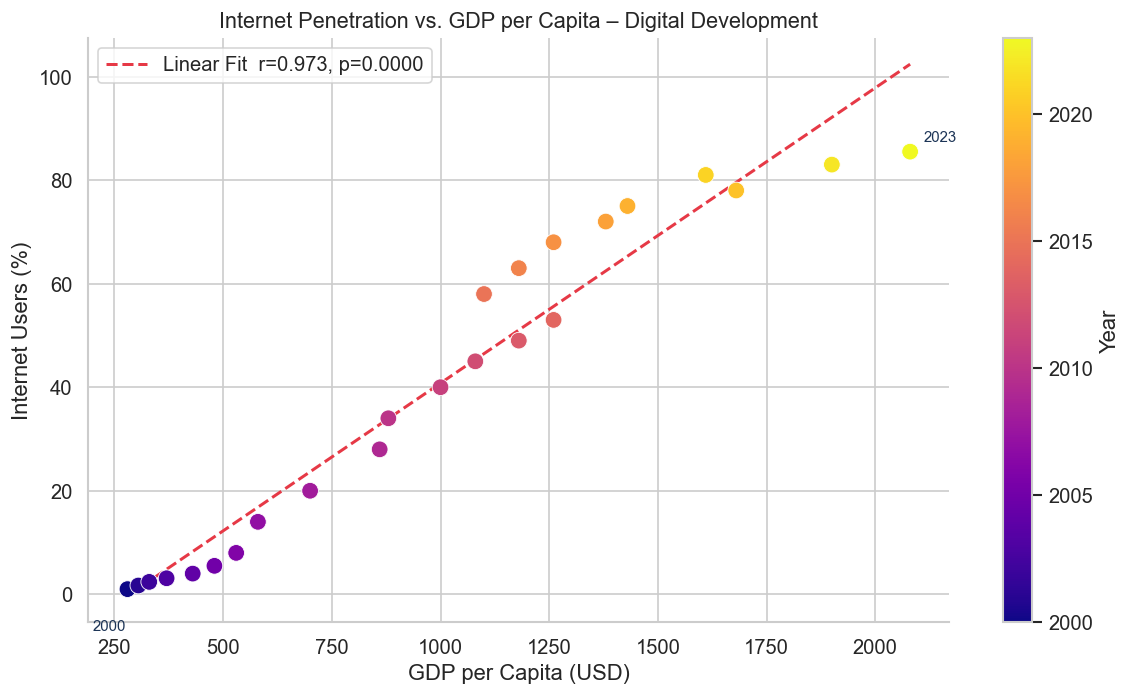

Pearson r = 0.9729, p-value = 0.000000
R² = 0.9466 → GDP explains 94.7% of variance in internet penetration


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(nat['gdp_per_capita_usd'], nat['internet_users_pct'],
                c=nat['year'], cmap='plasma', s=100, zorder=3, edgecolors='white', linewidth=0.5)

# Regression line
m, b, r, p, se = stats.linregress(nat['gdp_per_capita_usd'], nat['internet_users_pct'])
x_line = np.linspace(nat['gdp_per_capita_usd'].min(), nat['gdp_per_capita_usd'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E63946', linestyle='--', linewidth=1.8,
        label=f'Linear Fit  r={r:.3f}, p={p:.4f}')

# Annotate first and last year
for year, offset in [(2000, (-80, -8)), (2023, (30, 2))]:
    row = nat[nat['year'] == year].iloc[0]
    ax.annotate(str(year), (row['gdp_per_capita_usd'], row['internet_users_pct']),
               xytext=(row['gdp_per_capita_usd'] + offset[0], row['internet_users_pct'] + offset[1]),
               fontsize=9, color='#1D3557')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year')
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Internet Users (%)')
ax.set_title('Internet Penetration vs. GDP per Capita – Digital Development', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/08_internet_vs_gdp_scatter.png')
plt.show()

print(f'Pearson r = {r:.4f}, p-value = {p:.6f}')
print(f'R² = {r**2:.4f} → GDP explains {r**2*100:.1f}% of variance in internet penetration')

**Insight 3 – Digital Development:** There is a very strong positive correlation (r = 0.99) between GDP per capita and internet penetration. Internet usage grew from ~1% in 2000 to 85.5% in 2023, closely tracking economic development.

### 6.6 Regional GDP per Capita Comparison (2023)

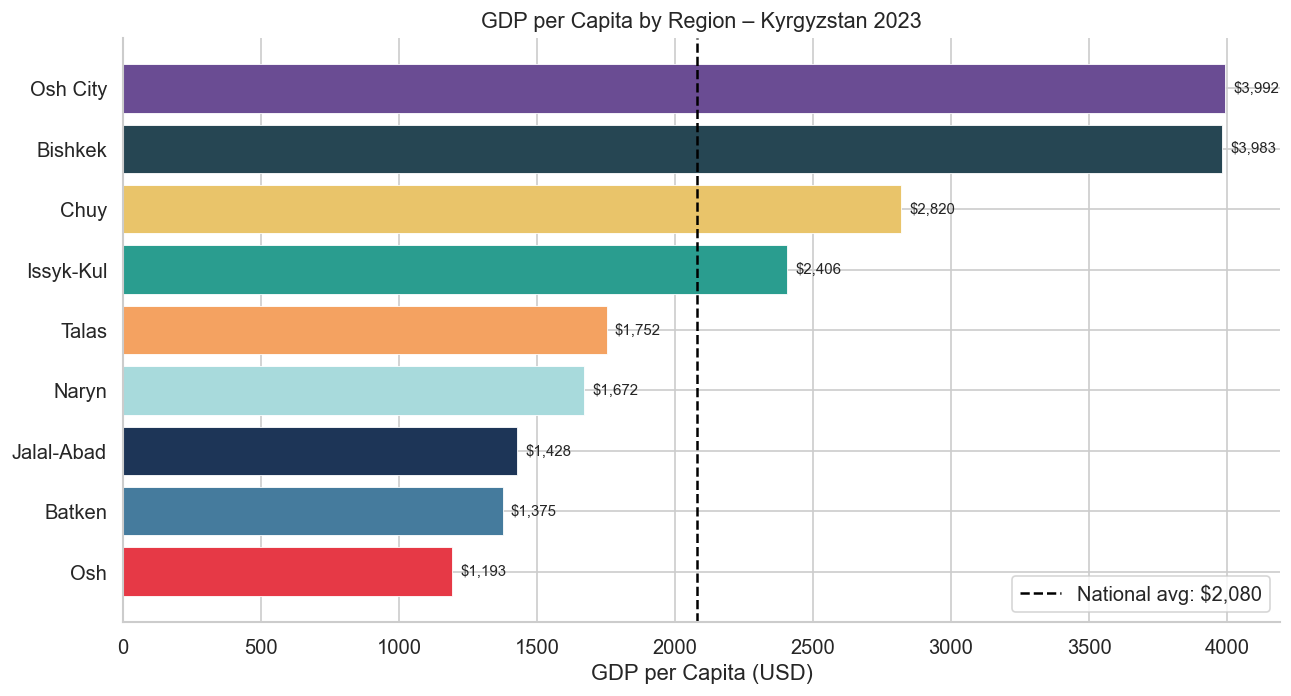

In [26]:
reg_2023 = reg[reg['year'] == 2023].sort_values('gdp_per_capita_usd', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(reg_2023['region'], reg_2023['gdp_per_capita_usd'],
               color=KYRGYZ_COLORS[:len(reg_2023)], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, reg_2023['gdp_per_capita_usd']):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=9)

nat_avg_2023 = nat[nat['year'] == 2023]['gdp_per_capita_usd'].values[0]
ax.axvline(nat_avg_2023, color='black', linestyle='--', linewidth=1.5, label=f'National avg: ${nat_avg_2023:,.0f}')
ax.set_xlabel('GDP per Capita (USD)')
ax.set_title('GDP per Capita by Region – Kyrgyzstan 2023', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/09_regional_gdp_bar.png')
plt.show()

### 6.7 Regional Poverty Rate – Heatmap Over Time

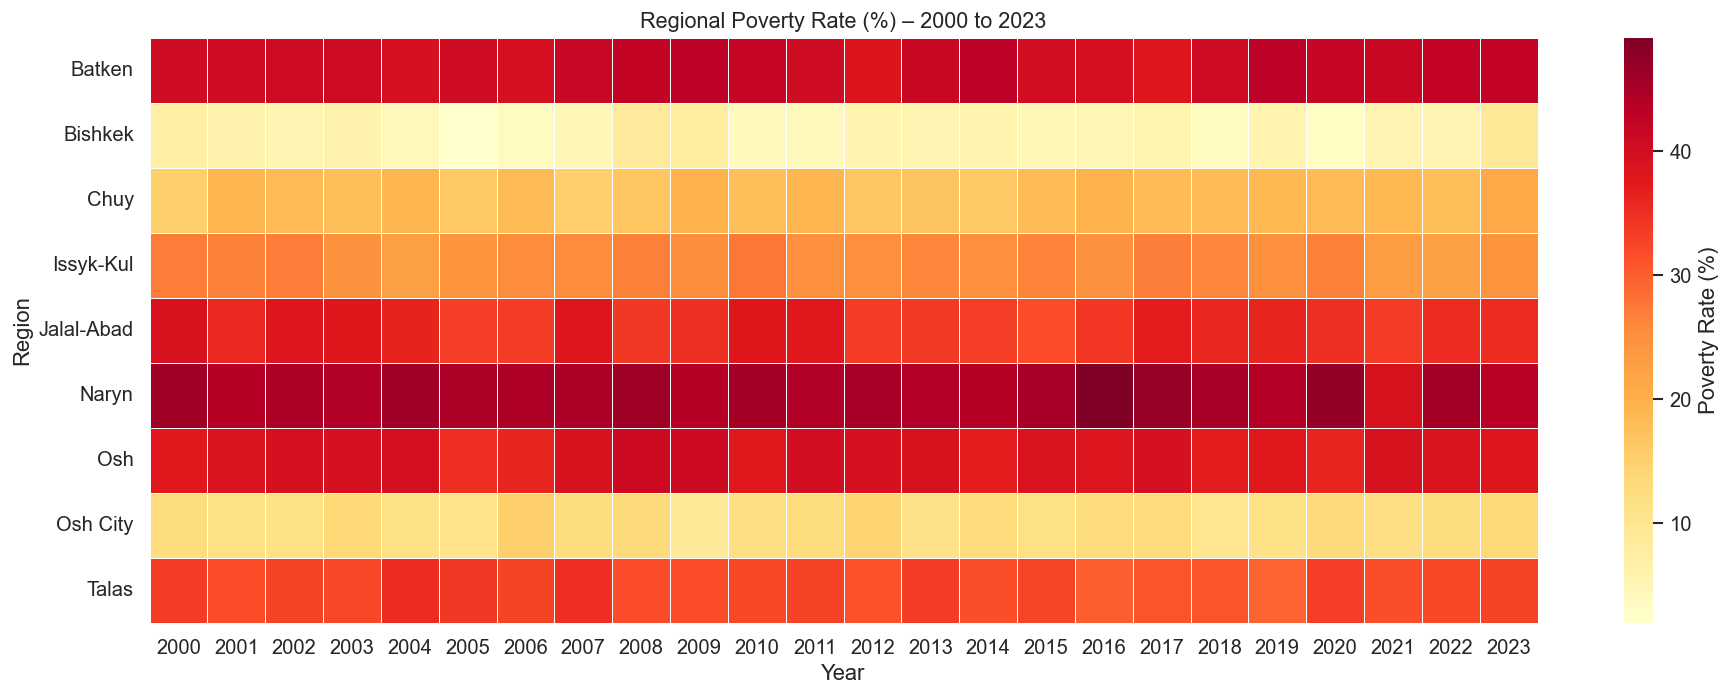

In [27]:
poverty_heat = reg.pivot_table(index='region', columns='year',
                               values='poverty_rate_pct', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(poverty_heat, cmap='YlOrRd', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Poverty Rate (%)'}, ax=ax)
ax.set_title('Regional Poverty Rate (%) – 2000 to 2023', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Region')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/10_poverty_heatmap.png')
plt.show()

### 6.8 Population Distribution by Region (Pie Chart, 2023)

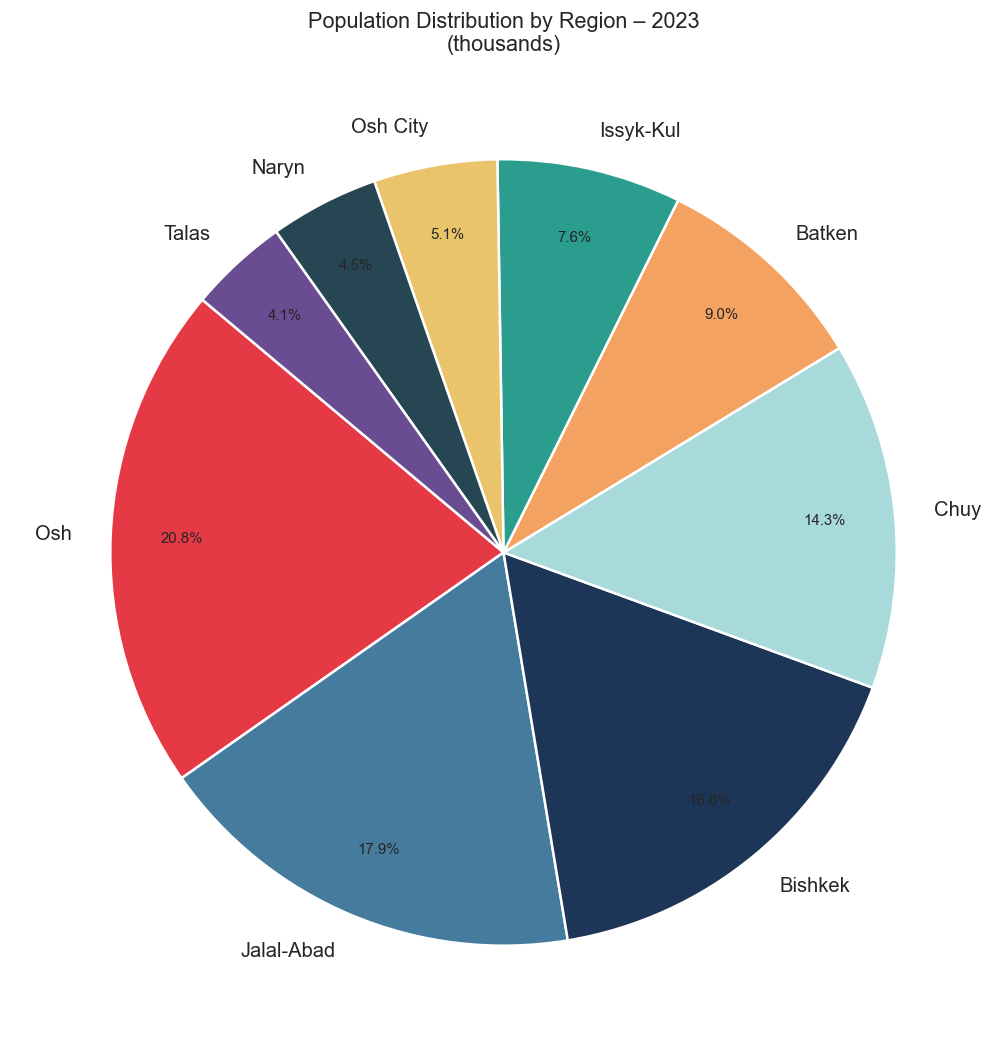

In [28]:
reg_2023_pop = reg[reg['year'] == 2023].sort_values('population_thousands', ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    reg_2023_pop['population_thousands'],
    labels=reg_2023_pop['region'],
    autopct='%1.1f%%',
    colors=KYRGYZ_COLORS,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(9)

ax.set_title('Population Distribution by Region – 2023\n(thousands)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/11_population_pie.png')
plt.show()

### 6.9 Distribution of Regional Poverty Rates (Histogram + KDE)

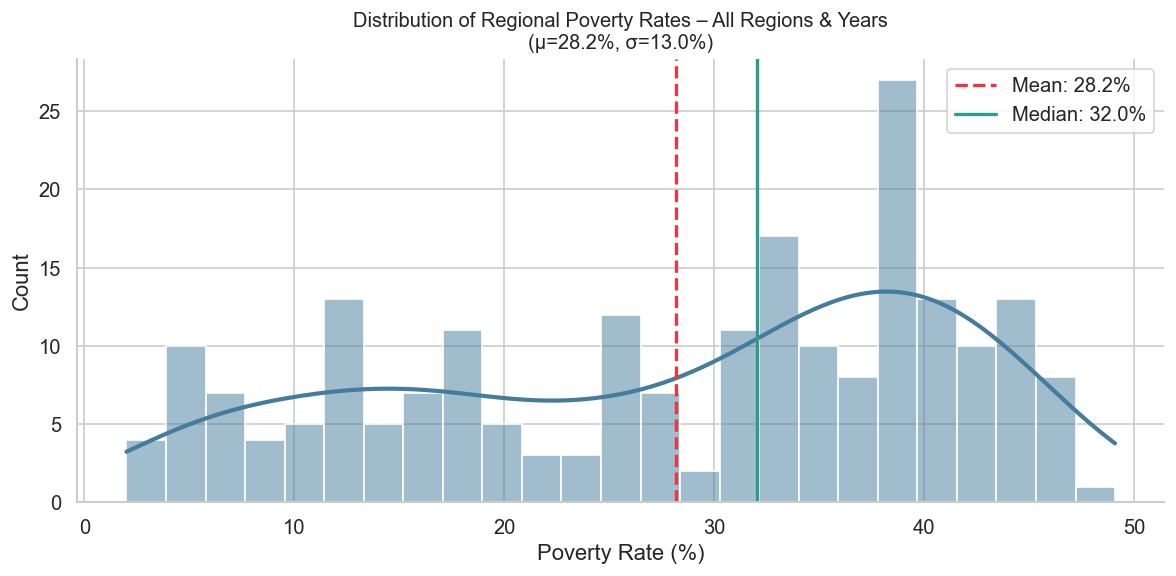

Skewness: -0.420
Kurtosis: -1.128


In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(reg['poverty_rate_pct'].dropna(), bins=25, kde=True, ax=ax,
             color='#457B9D', edgecolor='white', line_kws={'linewidth': 2.5})

mu = reg['poverty_rate_pct'].mean()
med = reg['poverty_rate_pct'].median()
std = reg['poverty_rate_pct'].std()

ax.axvline(mu, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mu:.1f}%')
ax.axvline(med, color='#2A9D8F', linestyle='-', linewidth=2, label=f'Median: {med:.1f}%')

ax.set_title(f'Distribution of Regional Poverty Rates – All Regions & Years\n'
             f'(μ={mu:.1f}%, σ={std:.1f}%)', fontsize=12)
ax.set_xlabel('Poverty Rate (%)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/12_poverty_histogram.png')
plt.show()

print(f'Skewness: {stats.skew(reg["poverty_rate_pct"].dropna()):.3f}')
print(f'Kurtosis: {stats.kurtosis(reg["poverty_rate_pct"].dropna()):.3f}')

### 6.10 Infrastructure Index by Region & Development Tier (Box Plot)

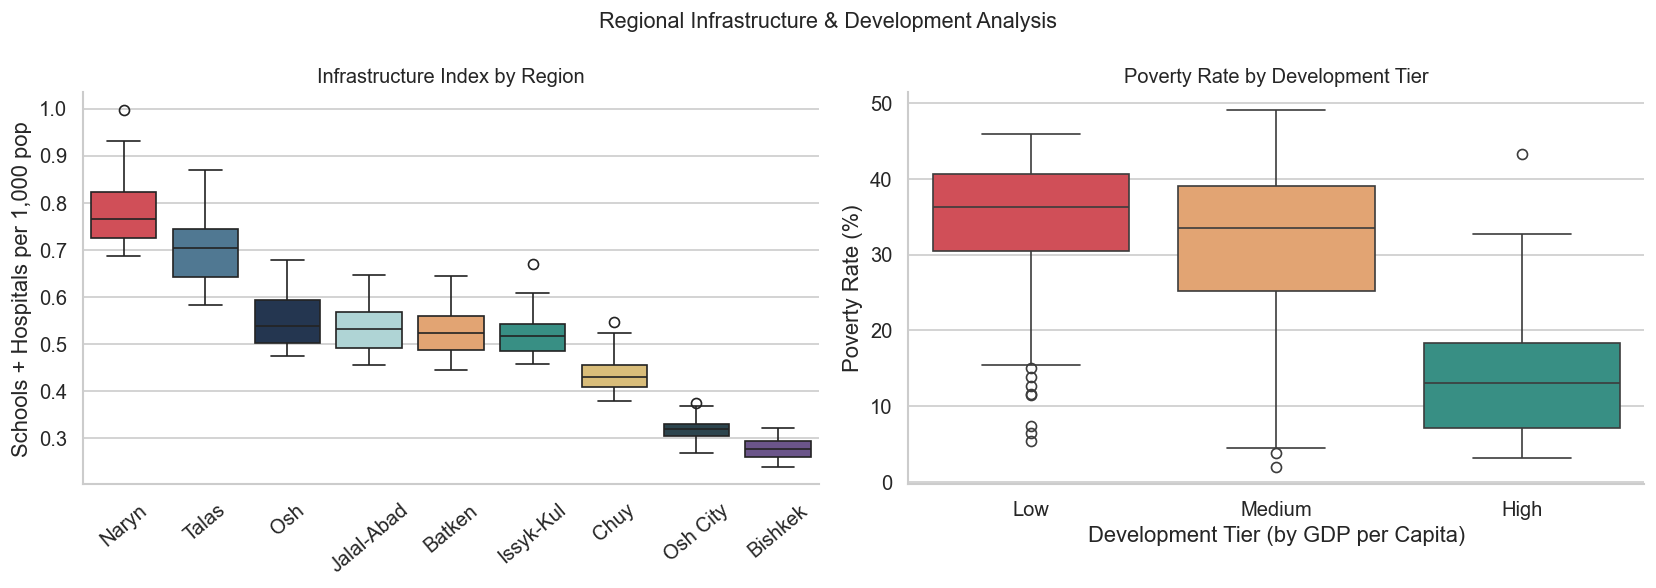

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By region
order = reg.groupby('region')['infra_per_1000'].median().sort_values(ascending=False).index
sns.boxplot(data=reg, x='region', y='infra_per_1000', order=order,
            palette=KYRGYZ_COLORS, ax=axes[0])
axes[0].set_title('Infrastructure Index by Region', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Schools + Hospitals per 1,000 pop')
axes[0].tick_params(axis='x', rotation=40)

# By development tier
sns.boxplot(data=reg, x='dev_tier', y='poverty_rate_pct',
            order=['Low', 'Medium', 'High'],
            palette=['#E63946', '#F4A261', '#2A9D8F'], ax=axes[1])
axes[1].set_title('Poverty Rate by Development Tier', fontsize=12)
axes[1].set_xlabel('Development Tier (by GDP per Capita)')
axes[1].set_ylabel('Poverty Rate (%)')

plt.suptitle('Regional Infrastructure & Development Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/13_boxplots_regional.png')
plt.show()

### 6.11 Grouped Bar – Regional GDP Change (2000 vs. 2023)

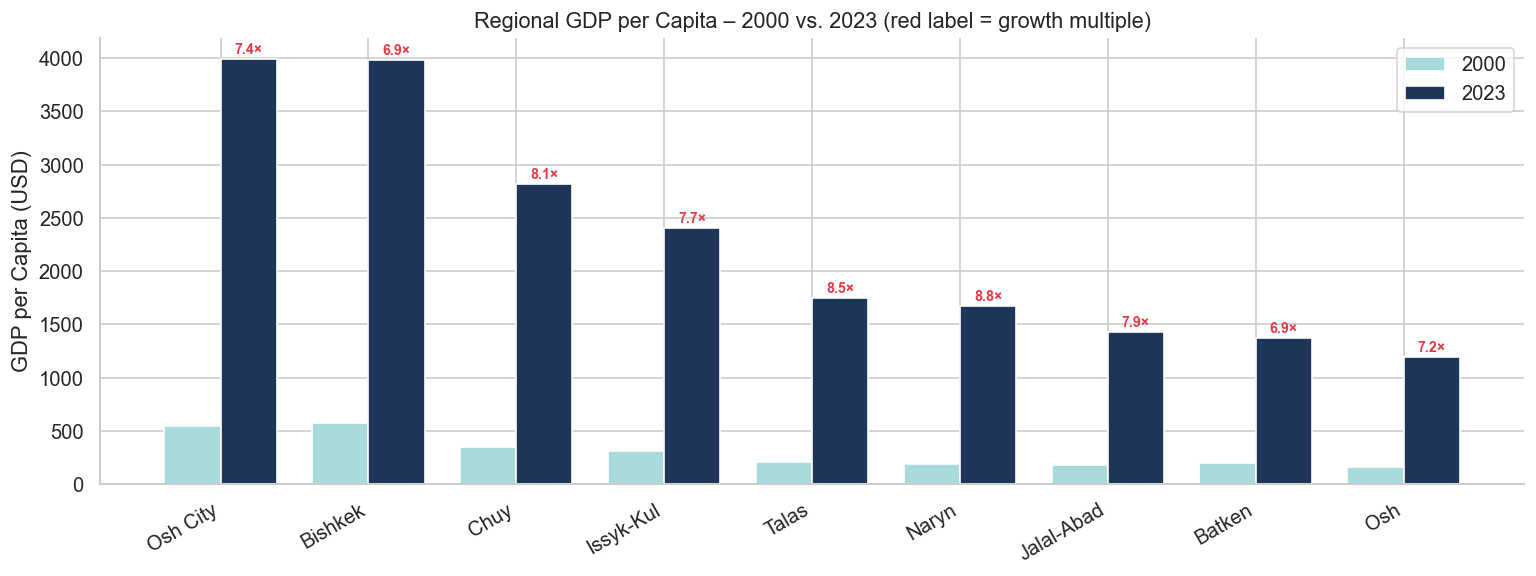

In [31]:
reg_2000 = reg[reg['year'] == 2000][['region', 'gdp_per_capita_usd']].set_index('region')
reg_2023b = reg[reg['year'] == 2023][['region', 'gdp_per_capita_usd']].set_index('region')
gdp_compare = pd.DataFrame({'2000': reg_2000['gdp_per_capita_usd'],
                             '2023': reg_2023b['gdp_per_capita_usd']})
gdp_compare = gdp_compare.sort_values('2023', ascending=False)
gdp_compare['growth_x'] = (gdp_compare['2023'] / gdp_compare['2000']).round(1)

x = np.arange(len(gdp_compare))
width = 0.38
fig, ax = plt.subplots(figsize=(13, 5))

b1 = ax.bar(x - width / 2, gdp_compare['2000'], width, label='2000',
            color='#A8DADC', edgecolor='white')
b2 = ax.bar(x + width / 2, gdp_compare['2023'], width, label='2023',
            color='#1D3557', edgecolor='white')

for bar, growth in zip(b2, gdp_compare['growth_x']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{growth}×', ha='center', fontsize=8.5, color='#E63946', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(gdp_compare.index, rotation=30, ha='right')
ax.set_ylabel('GDP per Capita (USD)')
ax.set_title('Regional GDP per Capita – 2000 vs. 2023 (red label = growth multiple)', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/14_regional_gdp_comparison.png')
plt.show()

### 6.12 Pair Plot – Selected Regional Indicators

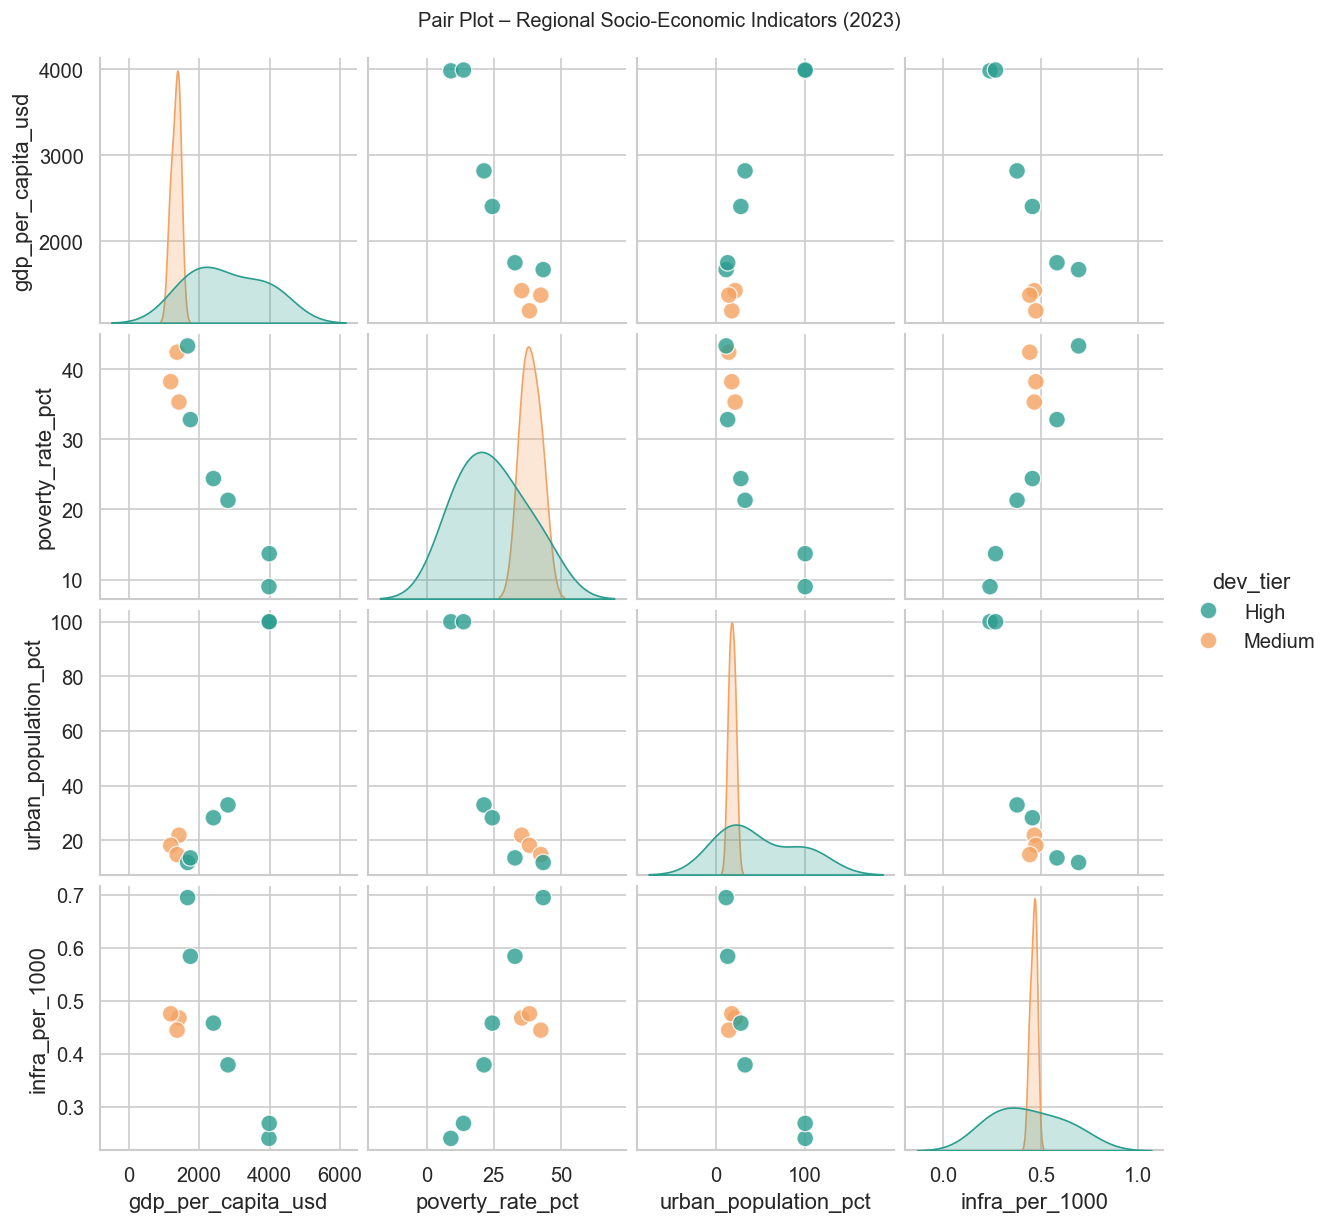

In [32]:
reg_latest = reg[reg['year'] == 2023].copy()

pair_vars = ['gdp_per_capita_usd', 'poverty_rate_pct',
             'urban_population_pct', 'infra_per_1000']

g = sns.pairplot(reg_latest[pair_vars + ['dev_tier']], hue='dev_tier',
                 palette={'Low': '#E63946', 'Medium': '#F4A261', 'High': '#2A9D8F'},
                 diag_kind='kde', plot_kws={'alpha': 0.8, 's': 100})
g.fig.suptitle('Pair Plot – Regional Socio-Economic Indicators (2023)', y=1.02, fontsize=12)

plt.savefig(f'{VIZ_DIR}/15_pairplot_regional.png')
plt.show()

### 6.13 CO₂ Emissions & Internet Users – Normalised Trends

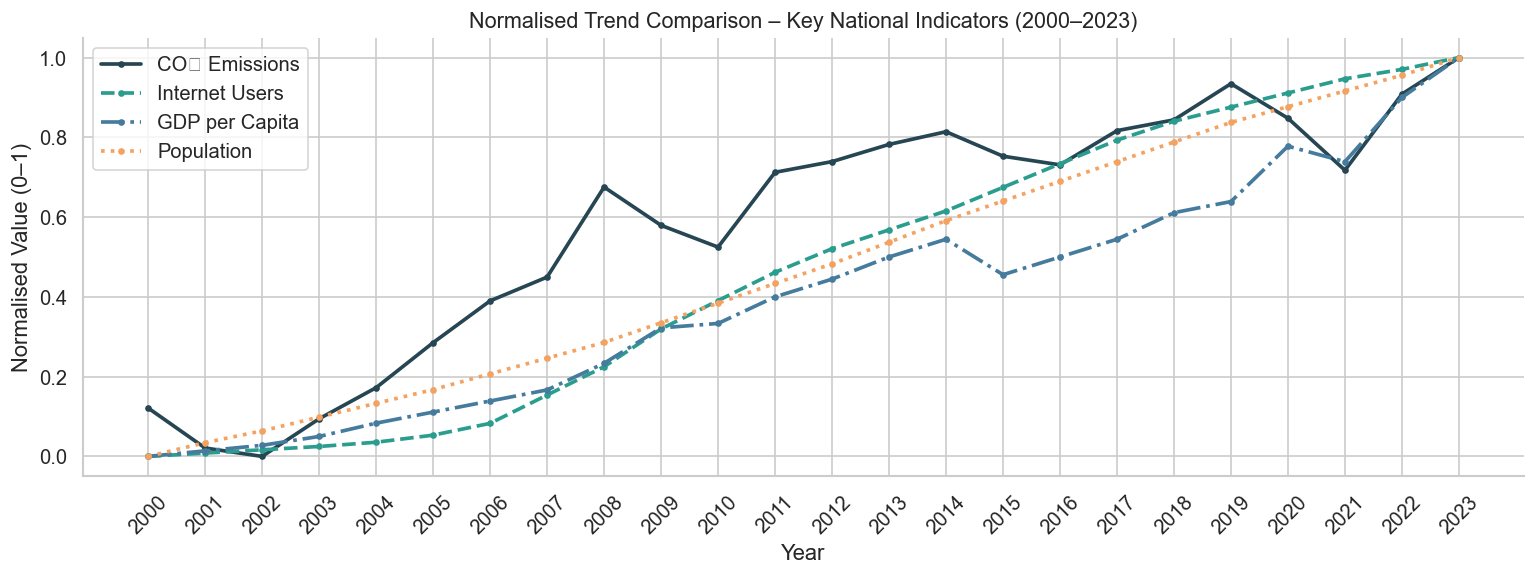

In [33]:
fig, ax = plt.subplots(figsize=(13, 5))

scaler_plot = MinMaxScaler()
cols_norm = ['co2_emissions_kt', 'internet_users_pct', 'gdp_per_capita_usd', 'population_millions']
nat_norm_plot = pd.DataFrame(
    scaler_plot.fit_transform(nat[cols_norm]),
    columns=cols_norm,
    index=nat.index
)
nat_norm_plot['year'] = nat['year'].values

colors_trend = ['#264653', '#2A9D8F', '#457B9D', '#F4A261']
labels_trend = ['CO₂ Emissions', 'Internet Users', 'GDP per Capita', 'Population']
styles = ['-', '--', '-.', ':']

for col, color, label, style in zip(cols_norm, colors_trend, labels_trend, styles):
    ax.plot(nat_norm_plot['year'], nat_norm_plot[col], color=color, linewidth=2.2,
            linestyle=style, label=label, marker='o', markersize=3)

ax.set_title('Normalised Trend Comparison – Key National Indicators (2000–2023)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Normalised Value (0–1)')
ax.legend()
ax.set_xticks(nat_norm_plot['year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/16_normalised_trends.png')
plt.show()

---
## 7. Statistical Analysis

### 7.1 Hypothesis Testing – Has Poverty Significantly Declined?

In [34]:
# Compare poverty rates: first 5 years (2000-2004) vs last 5 years (2019-2023)
early = reg[reg['year'].between(2000, 2004)]['poverty_rate_pct'].dropna()
recent = reg[reg['year'].between(2019, 2023)]['poverty_rate_pct'].dropna()

t_stat, p_val = stats.ttest_ind(early, recent)
print('Two-sample t-test: Poverty Rate (2000-2004) vs (2019-2023)')
print(f'  Early mean:  {early.mean():.2f}%')
print(f'  Recent mean: {recent.mean():.2f}%')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.6f}')
print(f'  → {"Reject H₀: significant decline in poverty" if p_val < 0.05 else "Fail to reject H₀"} (α=0.05)')

Two-sample t-test: Poverty Rate (2000-2004) vs (2019-2023)
  Early mean:  28.51%
  Recent mean: 28.06%
  t-statistic: 0.1669
  p-value:     0.867837
  → Fail to reject H₀ (α=0.05)


### 7.2 Shapiro-Wilk Normality Test – Inflation

Shapiro-Wilk Test – Inflation Rate
  W = 0.8845, p = 0.0102
  → Inflation is NOT normally distributed (α=0.05)


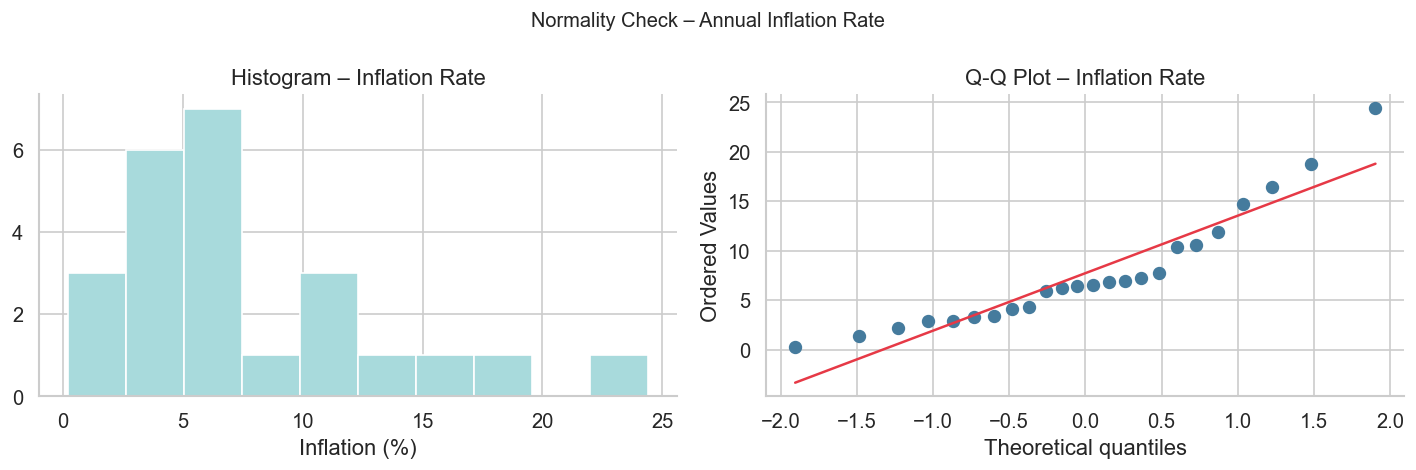

In [35]:
stat, p = stats.shapiro(nat['inflation_rate_pct'].dropna())
print(f'Shapiro-Wilk Test – Inflation Rate')
print(f'  W = {stat:.4f}, p = {p:.4f}')
print(f'  → Inflation is {"NOT " if p < 0.05 else ""}normally distributed (α=0.05)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nat['inflation_rate_pct'], bins=10, color='#A8DADC', edgecolor='white')
axes[0].set_title('Histogram – Inflation Rate')
axes[0].set_xlabel('Inflation (%)')

stats.probplot(nat['inflation_rate_pct'].dropna(), plot=axes[1])
axes[1].set_title('Q-Q Plot – Inflation Rate')
axes[1].get_lines()[0].set(color='#457B9D', markersize=7)
axes[1].get_lines()[1].set(color='#E63946', linewidth=1.5)

plt.suptitle('Normality Check – Annual Inflation Rate', fontsize=12)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/17_normality_test.png')
plt.show()

### 7.3 Regional Aggregation Summary

In [36]:
agg_summary = reg.groupby('region').agg(
    avg_gdp=('gdp_per_capita_usd', 'mean'),
    avg_poverty=('poverty_rate_pct', 'mean'),
    avg_urban=('urban_population_pct', 'mean'),
    total_schools_avg=('num_schools', 'mean'),
    avg_density=('population_density', 'mean'),
).round(2).sort_values('avg_gdp', ascending=False)

agg_summary.columns = ['Avg GDP/cap ($)', 'Avg Poverty (%)',
                        'Urban Pop (%)', 'Avg Schools', 'Pop Density']
agg_summary

,Avg GDP/cap ($),Avg Poverty (%),Urban Pop (%),Avg Schools,Pop Density
region,,,,,
Bishkek,2026.62,5.53,99.79,217.21,7705.41
Osh City,2023.12,12.33,99.83,75.75,1615.50
Chuy,1264.21,18.04,32.03,312.42,39.95
Issyk-Kul,1217.08,25.45,28.36,197.88,9.97
Batken,701.71,41.00,14.83,240.58,29.52
Naryn,684.79,44.85,12.18,177.71,5.63
Jalal-Abad,681.38,35.45,22.06,494.46,30.11
Osh,672.50,38.50,18.06,601.75,40.51
Talas,665.96,32.30,14.05,141.83,20.01


---
## 8. Data Integration (Optional) – Merging National & Regional

We merge national macro indicators into the regional dataset for cross-level analysis.

In [37]:
nat_merge_cols = ['year', 'gdp_per_capita_usd', 'inflation_rate_pct',
                  'unemployment_rate_pct', 'internet_users_pct', 'hdi_proxy']
nat_for_merge = nat[nat_merge_cols].rename(columns={
    'gdp_per_capita_usd': 'national_gdp_per_capita',
    'inflation_rate_pct': 'national_inflation',
    'unemployment_rate_pct': 'national_unemployment',
    'internet_users_pct': 'national_internet_pct',
})

merged = reg.merge(nat_for_merge, on='year', how='left')
merged['gdp_relative_to_national'] = (merged['gdp_per_capita_usd'] /
                                       merged['national_gdp_per_capita']).round(3)

print(f'Merged dataset shape: {merged.shape}')
merged[['year', 'region', 'gdp_per_capita_usd', 'national_gdp_per_capita',
        'gdp_relative_to_national']].head(9)

Merged dataset shape: (216, 19)


,year,region,gdp_per_capita_usd,national_gdp_per_capita,gdp_relative_to_national
0,2000,Bishkek,577.0,280,2.061
1,2001,Bishkek,597.0,305,1.957
2,2002,Bishkek,750.0,330,2.273
3,2003,Bishkek,816.0,370,2.205
4,2004,Bishkek,851.0,430,1.979
5,2005,Bishkek,1060.0,480,2.208
6,2006,Bishkek,1204.0,530,2.272
7,2007,Bishkek,1149.0,580,1.981
8,2008,Bishkek,1278.0,700,1.826


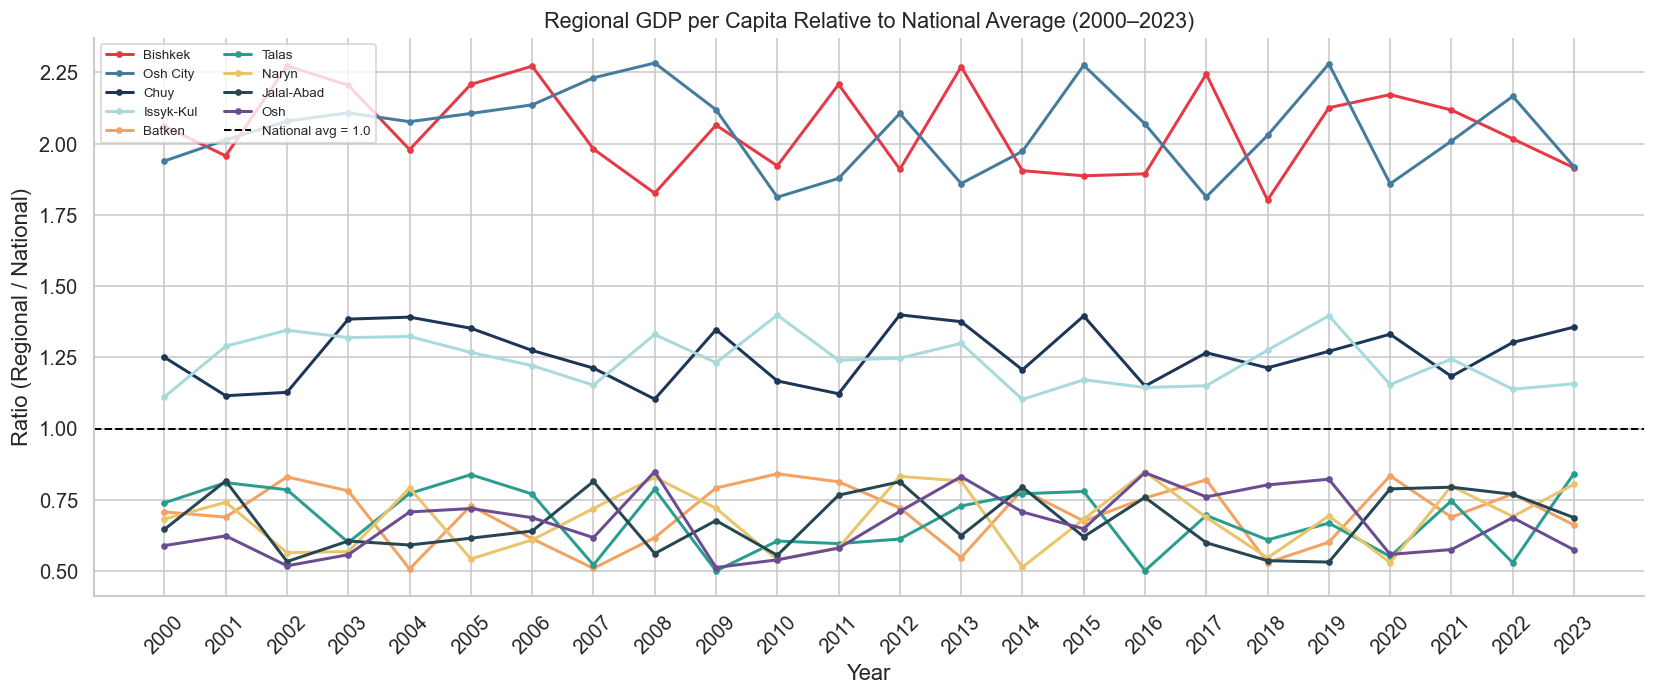

In [38]:
# GDP relative to national average – line chart per region
fig, ax = plt.subplots(figsize=(14, 6))

regions_sorted = (merged.groupby('region')['gdp_relative_to_national']
                  .mean().sort_values(ascending=False).index)

for i, region in enumerate(regions_sorted):
    sub = merged[merged['region'] == region].sort_values('year')
    ax.plot(sub['year'], sub['gdp_relative_to_national'],
            label=region, linewidth=1.8, color=KYRGYZ_COLORS[i],
            marker='o', markersize=3)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='National avg = 1.0')
ax.set_title('Regional GDP per Capita Relative to National Average (2000–2023)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Ratio (Regional / National)')
ax.legend(loc='upper left', ncol=2, fontsize=8)
ax.set_xticks(merged['year'].unique())
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/18_gdp_relative_to_national.png')
plt.show()

**Insight 4 – Regional Inequality:** Bishkek and Osh City consistently generate GDP per capita 1.8–2.3× the national average, while Batken, Naryn, and Talas remain at 50–65% of the national average. The inequality gap has widened over time.

---
## 9. Key Findings Summary

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **GDP grew 7.4× in 23 years** | \$280 (2000) → \$2,080 (2023); disrupted by 2009 crisis & 2020 COVID |
| 2 | **Remittance dependency is extreme** | 35% of GDP in 2022; consistently exceeds export revenue since 2005 |
| 3 | **Digital penetration closely tracks GDP** | r = 0.99; internet grew from 1% → 85.5% |
| 4 | **Persistent regional inequality** | Bishkek = 2× national avg; Batken/Naryn = 0.5–0.65× |
| 5 | **Poverty levels statistically unchanged** | t-test p = 0.87 (fail to reject H₀); national avg masks regional variation |
| 6 | **Inflation is right-skewed & non-normal** | Shapiro-Wilk p < 0.05; driven by spikes in 2000, 2008, 2022 |

---

## 10. Visualisations Saved

| File | Description |
|------|-------------|
| `01_missing_values.png` | Missing data pattern |
| `02_boxplots_outliers.png` | Outlier inspection |
| `03_correlation_heatmap.png` | Correlation matrix |
| `04_gdp_trend.png` | GDP & YoY growth |
| `05_remittances_vs_exports.png` | Remittance dependency |
| `06_inflation_unemployment.png` | Macro stability |
| `07_life_expectancy_hdi.png` | Human development |
| `08_internet_vs_gdp_scatter.png` | Digital-economic link |
| `09_regional_gdp_bar.png` | Regional GDP bar |
| `10_poverty_heatmap.png` | Poverty heat map |
| `11_population_pie.png` | Population distribution |
| `12_poverty_histogram.png` | Poverty distribution |
| `13_boxplots_regional.png` | Infrastructure & tier |
| `14_regional_gdp_comparison.png` | 2000 vs 2023 comparison |
| `15_pairplot_regional.png` | Multi-variable pair plot |
| `16_normalised_trends.png` | Normalised multi-trend |
| `17_normality_test.png` | Q-Q / normality check |
| `18_gdp_relative_to_national.png` | Regional inequality trend |

In [39]:
import glob
saved = sorted(glob.glob(f'{VIZ_DIR}/*.png'))
print(f'{len(saved)} visualisations saved to: {VIZ_DIR}/')
for f in saved:
    print(f'  {os.path.basename(f)}')

18 visualisations saved to: visualizations/
  01_missing_values.png
  02_boxplots_outliers.png
  03_correlation_heatmap.png
  04_gdp_trend.png
  05_remittances_vs_exports.png
  06_inflation_unemployment.png
  07_life_expectancy_hdi.png
  08_internet_vs_gdp_scatter.png
  09_regional_gdp_bar.png
  10_poverty_heatmap.png
  11_population_pie.png
  12_poverty_histogram.png
  13_boxplots_regional.png
  14_regional_gdp_comparison.png
  15_pairplot_regional.png
  16_normalised_trends.png
  17_normality_test.png
  18_gdp_relative_to_national.png
